<a href="https://colab.research.google.com/github/iampedroalz/iampedroalz/blob/master/NeuralNetwork_FeatureEngineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [0]:
!pip install --upgrade tensorflow

Requirement already up-to-date: tensorflow in /usr/local/lib/python3.6/dist-packages (2.1.0)


In [0]:
from __future__ import absolute_import, division, print_function, unicode_literals

import numpy as np
import pandas as pd

import tensorflow as tf

from tensorflow import feature_column
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

from sklearn import preprocessing

In [0]:
#Read files 
train_df = pd.read_csv("/content/drive/My Drive/Datathon/data/Modelar_UH2020.txt",sep='|')#sep='|'
test_df = pd.read_csv("/content/drive/My Drive/Datathon/data/Estimar_UH2020.txt",sep='|')#sep='|'

In [0]:
dict_cadastral = {'2':2, '8':8, '5':5, '6':6, '4':4, '7':7, '3':3, 'C':13, '1':1, '9':9, 'B':12, 'A':11}
dict_CLASE = {'RESIDENTIAL':0, 'INDUSTRIAL':1, 'PUBLIC':2, 'OFFICE':3, 'OTHER':4, 'RETAIL':5,'AGRICULTURE':6,'NON-RES':1}

In [0]:
train_df.CLASE = train_df.CLASE.map(dict_CLASE)
labels = train_df.CLASE
train_df = train_df.drop(['CLASE','ID'], axis=1)
train_df.CADASTRALQUALITYID = train_df.CADASTRALQUALITYID.map(dict_cadastral).astype(int,errors="ignore")

In [0]:
def df_rare_values(df, columns):
  for col in columns: 
    rare_values = df[col].value_counts()/len(df) < 0.10
    rare_values = rare_values.index[rare_values.values]
    df['RARE_' + col] = [1.0 if value in rare_values else 0.0 for value in df[col] ]
  return df

train_df = df_rare_values(train_df, ['MAXBUILDINGFLOOR','CADASTRALQUALITYID'])

In [0]:
train_df['CADASTRAL_nan'] = train_df.CADASTRALQUALITYID.isna().astype(int)
train_df['CADASTRALQUALITYID'] = train_df['CADASTRALQUALITYID'].fillna(99)
train_df['MAXBUILDINGFLOOR_nan'] = train_df.MAXBUILDINGFLOOR.isna().astype(int)
train_df['MAXBUILDINGFLOOR'] = train_df['MAXBUILDINGFLOOR'].fillna(99)

In [0]:
# import labelencoder
from sklearn.preprocessing import LabelEncoder
# instantiate labelencoder object
le = LabelEncoder()

year_bins =  pd.qcut(train_df['CONTRUCTIONYEAR'], q=20, precision=0)
area_bins =  pd.qcut(train_df['AREA'], q=50, precision=0)
x_bins =  pd.qcut(train_df['X'], q=50, precision=0)
y_bins =  pd.qcut(train_df['Y'], q=50, precision=0)
train_df['Y_CAT'] = le.fit_transform(y_bins)
y_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
train_df['X_CAT'] = le.fit_transform(x_bins)
x_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
train_df['YEAR_CAT'] = le.fit_transform(year_bins)
year_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
train_df['AREA_CAT'] = le.fit_transform(area_bins)
area_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

# FEATURE ENGINEERING

Merged groupby features

In [0]:
def grouped_median(df,col_group,col_used):
  df1 = df.groupby(col_group)[col_used].median()
  df2 = df.merge(df1, how='left', on=col_group)
  df2[col_used + col_group + '_median'] = df2[col_used + '_x'] - df2[col_used + '_y']
  df2 = df2.rename(columns={col_used+'_x': col_used, col_used + '_y': col_used + col_group + '_median' })
  return df2
def grouped_mean(df,col_group,col_used):
  df1 = df.groupby(col_group)[col_used].mean()
  df2 = df.merge(df1, how='left', on=col_group)
  df2[col_used + col_group + '_subs_mean'] = df2[col_used + '_x'] - df2[col_used + '_y']
  df2 = df2.rename(columns={col_used+'_x': col_used, col_used + '_y': col_used + col_group + '_mean' })
  return df2
def grouped_std(df,col_group,col_used):
  df1 = df.groupby(col_group)[col_used].std()
  df2 = df.merge(df1, how='left', on=col_group)
  df2[col_used + col_group + '_std'] = df2[col_used + '_x'] - df2[col_used + '_y']
  df2 = df2.rename(columns={col_used+'_x': col_used, col_used + '_y': col_used + col_group + '_std' })
  return df2


In [0]:
train_df = grouped_median(train_df, 'CADASTRALQUALITYID', 'AREA')
train_df = grouped_mean(train_df, 'CADASTRALQUALITYID', 'AREA')
train_df = grouped_std(train_df, 'CADASTRALQUALITYID', 'AREA')

In [0]:
train_df = grouped_median(train_df, 'CADASTRALQUALITYID', 'GEOM_R1')
train_df = grouped_median(train_df, 'CADASTRALQUALITYID', 'GEOM_R2')
train_df = grouped_median(train_df, 'CADASTRALQUALITYID', 'GEOM_R3')
train_df = grouped_median(train_df, 'CADASTRALQUALITYID', 'GEOM_R4')

train_df = grouped_mean(train_df, 'CADASTRALQUALITYID', 'GEOM_R1')
train_df = grouped_mean(train_df, 'CADASTRALQUALITYID', 'GEOM_R2')
train_df = grouped_mean(train_df, 'CADASTRALQUALITYID', 'GEOM_R3')
train_df = grouped_mean(train_df, 'CADASTRALQUALITYID', 'GEOM_R4')

train_df = grouped_median(train_df, 'CONTRUCTIONYEAR', 'GEOM_R1')
train_df = grouped_median(train_df, 'CONTRUCTIONYEAR', 'GEOM_R2')
train_df = grouped_median(train_df, 'CONTRUCTIONYEAR', 'GEOM_R3')
train_df = grouped_median(train_df, 'CONTRUCTIONYEAR', 'GEOM_R4')
train_df = grouped_median(train_df, 'CONTRUCTIONYEAR', 'AREA')

train_df = grouped_median(train_df, 'MAXBUILDINGFLOOR', 'GEOM_R1')
train_df = grouped_median(train_df, 'MAXBUILDINGFLOOR', 'GEOM_R2')
train_df = grouped_median(train_df, 'MAXBUILDINGFLOOR', 'GEOM_R3')
train_df = grouped_median(train_df, 'MAXBUILDINGFLOOR', 'GEOM_R4')
train_df = grouped_median(train_df, 'MAXBUILDINGFLOOR', 'AREA')

train_df = grouped_median(train_df, 'X_CAT', 'GEOM_R1')
train_df = grouped_median(train_df, 'X_CAT', 'GEOM_R2')
train_df = grouped_median(train_df, 'X_CAT', 'GEOM_R3')
train_df = grouped_median(train_df, 'X_CAT', 'GEOM_R4')
train_df = grouped_median(train_df, 'X_CAT', 'AREA')

train_df = grouped_median(train_df, 'Y_CAT', 'GEOM_R1')
train_df = grouped_median(train_df, 'Y_CAT', 'GEOM_R2')
train_df = grouped_median(train_df, 'Y_CAT', 'GEOM_R3')
train_df = grouped_median(train_df, 'Y_CAT', 'GEOM_R4')
train_df = grouped_median(train_df, 'Y_CAT', 'AREA')

train_df = grouped_median(train_df, 'YEAR_CAT', 'GEOM_R1')
train_df = grouped_median(train_df, 'YEAR_CAT', 'GEOM_R2')
train_df = grouped_median(train_df, 'YEAR_CAT', 'GEOM_R3')
train_df = grouped_median(train_df, 'YEAR_CAT', 'GEOM_R4')
train_df = grouped_median(train_df, 'YEAR_CAT', 'AREA')

In [0]:
train_df['inf_total'] = train_df['Q_NIR_8_0_1'] + train_df['Q_NIR_8_0_2'] \
+ train_df['Q_NIR_8_0_3'] + train_df['Q_NIR_8_0_4'] + train_df['Q_NIR_8_0_5'] \
+ train_df['Q_NIR_8_0_6'] + train_df['Q_NIR_8_0_7'] + train_df['Q_NIR_8_0_8'] \
+ train_df['Q_NIR_8_0_9'] + train_df['Q_NIR_8_1_0']

In [0]:
train_df.loc[train_df['MAXBUILDINGFLOOR'] < 0.8, 'MAXBUILDINGFLOOR'] = 0.1
train_df['altura_piso'] = train_df['inf_total']/(train_df['MAXBUILDINGFLOOR'] * 1000 +0.0005)
train_df['altura_piso_inf0'] =  (train_df['Q_NIR_8_0_0'] * 1000)/(train_df['MAXBUILDINGFLOOR']+0.0005)

In [0]:
train_df['red'] = train_df['Q_R_4_0_0'] + train_df['Q_R_4_0_1'] + train_df['Q_R_4_0_2'] \
+ train_df['Q_R_4_0_3'] + train_df['Q_R_4_0_4'] + train_df['Q_R_4_0_5'] + train_df['Q_R_4_0_6']\
+ train_df['Q_R_4_0_7'] + train_df['Q_R_4_0_8'] + train_df['Q_R_4_0_9'] + train_df['Q_R_4_1_0']

train_df['green'] = train_df['Q_G_3_0_0'] + train_df['Q_G_3_0_1'] + train_df['Q_G_3_0_2'] \
+ train_df['Q_G_3_0_3'] +  train_df['Q_G_3_0_4'] + train_df['Q_G_3_0_5'] + train_df['Q_G_3_0_6']\
+ train_df['Q_G_3_0_7'] + train_df['Q_G_3_0_8'] + train_df['Q_G_3_0_9'] + train_df['Q_G_3_1_0']

train_df['blue'] = train_df['Q_B_2_0_0'] + train_df['Q_B_2_0_1'] + train_df['Q_B_2_0_2'] \
+ train_df['Q_B_2_0_3'] + train_df['Q_B_2_0_4'] + train_df['Q_B_2_0_5'] +  train_df['Q_B_2_0_6']\
+ train_df['Q_B_2_0_7'] + train_df['Q_B_2_0_8'] + train_df['Q_B_2_0_9'] + train_df['Q_B_2_1_0']

In [0]:
train_df['canal_0'] = train_df['Q_R_4_0_0'] + train_df['Q_G_3_0_0'] + train_df['Q_B_2_0_0']
train_df['canal_1'] = train_df['Q_R_4_0_1'] + train_df['Q_G_3_0_1'] + train_df['Q_B_2_0_1']
train_df['canal_2'] = train_df['Q_R_4_0_2'] + train_df['Q_G_3_0_2'] + train_df['Q_B_2_0_2']
train_df['canal_3'] = train_df['Q_R_4_0_3'] + train_df['Q_G_3_0_3'] + train_df['Q_B_2_0_3']
train_df['canal_4'] = train_df['Q_R_4_0_4'] + train_df['Q_G_3_0_4'] + train_df['Q_B_2_0_4']
train_df['canal_5'] = train_df['Q_R_4_0_5'] + train_df['Q_G_3_0_5'] + train_df['Q_B_2_0_5']
train_df['canal_6'] = train_df['Q_R_4_0_6'] + train_df['Q_G_3_0_6'] + train_df['Q_B_2_0_6']
train_df['canal_7'] = train_df['Q_R_4_0_7'] + train_df['Q_G_3_0_7'] + train_df['Q_B_2_0_7']
train_df['canal_8'] = train_df['Q_R_4_0_8'] + train_df['Q_G_3_0_8'] + train_df['Q_B_2_0_8']
train_df['canal_9'] = train_df['Q_R_4_0_9'] + train_df['Q_G_3_0_9'] + train_df['Q_B_2_0_9']
train_df['canal_10'] = train_df['Q_R_4_1_0'] + train_df['Q_G_3_1_0'] + train_df['Q_B_2_1_0']

In [0]:
train_df['GEOM_R2+GEOM_R4']=train_df['GEOM_R2']+train_df['GEOM_R4']
train_df['GEOM_R2_GEOM_R4']=train_df['GEOM_R2']*train_df['GEOM_R4']

train_df['GEOM_R4+GEOM_R3']=train_df['GEOM_R4']+train_df['GEOM_R3']
train_df['GEOM_R4_GEOM_R3']=train_df['GEOM_R4']*train_df['GEOM_R3']

train_df['GEOM_R2+GEOM_R3']=train_df['GEOM_R2']+train_df['GEOM_R3']
train_df['GEOM_R2_GEOM_R3']=train_df['GEOM_R2']*train_df['GEOM_R3']

In [0]:
from sklearn import preprocessing


def localiza_grid_XY(numero_grids, name, desplazado = False, X_train_ = train_df):
    if desplazado:
        pass
    else:
        tramo_x = (np.max(X_train_["X"])+1 - np.min(X_train_["X"]))/(numero_grids)
        tramo_y = (np.max(X_train_["Y"])+1 - np.min(X_train_["Y"]))/(numero_grids)
        X_train_[name] = ((X_train_["X"]- np.min(X_train_["X"]))//tramo_x).astype(str)\
                    + "_"+ ((X_train_["Y"]- np.min(X_train_["Y"]))//tramo_y).astype(str)
        le = preprocessing.LabelEncoder()
        X_train_[name] = le.fit_transform(X_train_[name])

    if 'freq_'+name not in list(X_train_) :   
        aux = X_train_.groupby(name).agg({name:['count']}).reset_index().fillna(0)
        aux.columns = [name,'freq_'+name]
        aux['freq_dens_'+name] = aux['freq_'+name]  /tramo_x/tramo_y
        X_train_ = pd.merge(X_train_,aux,on=name,how='left')
        #X_train_['freq_dens_'+name] = X_train_['freq_'+name]
        
    #X_train_ = X_train_.drop(columns = [name])
    return X_train_

train_df = localiza_grid_XY(8,"grid_8",X_train_ = train_df)
train_df = localiza_grid_XY(16,"grid_16",X_train_ = train_df)
train_df = localiza_grid_XY(32,"grid_32",X_train_ = train_df)
train_df = localiza_grid_XY(64,"grid_64",X_train_ = train_df)

for i in [s for s in list(train_df) if "freq_dens_grid_" in s]:
    if "freq_dens_grid" in train_df:
        train_df["freq_dens_grid"] += train_df[i]
    else:
        train_df["freq_dens_grid"] = train_df[i]

In [0]:
train_df

,X,Y,Q_R_4_0_0,Q_R_4_0_1,Q_R_4_0_2,Q_R_4_0_3,Q_R_4_0_4,Q_R_4_0_5,Q_R_4_0_6,Q_R_4_0_7,Q_R_4_0_8,Q_R_4_0_9,Q_R_4_1_0,Q_G_3_0_0,Q_G_3_0_1,Q_G_3_0_2,Q_G_3_0_3,Q_G_3_0_4,Q_G_3_0_5,Q_G_3_0_6,Q_G_3_0_7,Q_G_3_0_8,Q_G_3_0_9,Q_G_3_1_0,Q_B_2_0_0,Q_B_2_0_1,Q_B_2_0_2,Q_B_2_0_3,Q_B_2_0_4,Q_B_2_0_5,Q_B_2_0_6,Q_B_2_0_7,Q_B_2_0_8,Q_B_2_0_9,Q_B_2_1_0,Q_NIR_8_0_0,Q_NIR_8_0_1,Q_NIR_8_0_2,Q_NIR_8_0_3,Q_NIR_8_0_4,...,GEOM_R4YEAR_CAT_median,GEOM_R4YEAR_CAT_median,AREAYEAR_CAT_median,AREAYEAR_CAT_median,inf_total,altura_piso,altura_piso_inf0,red,green,blue,canal_0,canal_1,canal_2,canal_3,canal_4,canal_5,canal_6,canal_7,canal_8,canal_9,canal_10,GEOM_R2+GEOM_R4,GEOM_R2_GEOM_R4,GEOM_R4+GEOM_R3,GEOM_R4_GEOM_R3,GEOM_R2+GEOM_R3,GEOM_R2_GEOM_R3,grid_8,freq_grid_8,freq_dens_grid_8,grid_16,freq_grid_16,freq_dens_grid_16,grid_32,freq_grid_32,freq_dens_grid_32,grid_64,freq_grid_64,freq_dens_grid_64,freq_dens_grid
0,2207357872,165920300,0.000000e+00,443.001300,616.001697,746.998401,872.996472,1009.000946,1159.002319,1342.002466,1572.003418,1943.686816,6512.787270,1.283357e-10,428.996347,574.000940,676.002960,778.003931,880.999176,997.000220,1130.001782,1311.997949,1626.996155,8627.098641,155.003632,402.000092,458.999939,510.000061,567.999939,632.000610,681.000916,726.109186,791.000269,902.999719,1980.172280,0.000013,892.016479,1244.014185,1497.998303,1731.204688,...,1.022715,-0.169588,134.361042,10.065858,28733.156101,287.330124,0.133621,16217.481105,17031.098101,7807.286641,1.550036e+02,1273.997739,1649.002576,1933.001422,2219.000342,2522.000732,2837.003455,3198.113434,3675.001636,4473.682690,17120.058190,0.920376,0.057372,0.910499,0.048946,0.124622,0.003858,31,1930,5.263695e-10,151,256,2.792759e-10,128,146,6.370980e-10,592,50,8.727371e-10,2.315480e-09
1,2189757160,165463267,5.879611e-05,443.899011,627.999060,770.001611,904.999988,1032.998474,1165.001636,1316.000110,1505.990771,1804.993469,6269.935600,1.352518e-11,433.998392,565.000110,662.996521,746.001318,828.998413,912.000330,1011.997162,1142.202637,1384.994580,5357.790999,120.000275,419.000000,472.999939,509.999808,541.999976,572.000000,602.999939,636.000122,673.000122,745.000000,3647.195402,0.000030,846.002728,1139.006982,1363.993860,1558.000513,...,0.987835,0.194118,200.102164,-161.759614,23375.360966,23.375349,0.029660,15841.819790,13045.980461,8940.195582,1.200003e+02,1296.897403,1665.999109,1942.997940,2193.001282,2433.996887,2680.001904,2963.997394,3321.193530,3934.988049,15274.922001,1.307109,0.147929,1.329882,0.174845,0.273085,0.018514,22,12779,3.485221e-09,116,4862,5.304059e-09,68,1337,5.834247e-09,283,597,1.042048e-08,2.504401e-08
2,2240147335,165690752,0.000000e+00,353.502274,523.003601,644.001831,760.997131,876.999634,1006.997498,1168.995544,1375.008179,1719.003235,5010.767611,0.000000e+00,379.001587,507.003815,600.000519,684.000488,768.997528,867.001587,992.991760,1165.998413,1443.000366,5240.232771,83.000389,363.000031,429.002502,473.000015,510.000092,549.000244,590.999939,635.999817,692.999817,796.498779,1947.739721,0.000005,807.001373,1124.002441,1365.009583,1570.995117,...,0.979374,0.422178,150.465408,-41.671023,23507.063231,23.507051,0.005156,13439.276537,12648.228834,7071.241346,8.300039e+01,1095.503891,1459.009918,1717.002365,1954.997711,2194.997406,2464.999023,2797.987122,3234.006409,3958.502380,12198.740104,1.459820,0.081666,1.483218,0.114459,0.139934,0.004759,38,6624,1.806566e-09,27,1878,2.048750e-09,265,642,2.801486e-09,1001,235,4.101864e-09,1.075867e-08
3,2227146459,165934099,0.000000e+00,268.000613,376.999609,478.003784,575.001233,683.997742,809.005994,955.002960,1136.997144,1447.997290,5465.430281,6.341585e-06,310.999088,405.998712,485.000607,558.997925,641.001007,731.994189,838.004376,974.797485,1217.996167,5343.168796,0.001450,256.999487,295.999969,329.000092,366.000043,411.000549,457.000061,506.000000,565.999817,663.999817,1424.396092,0.002285,1200.994470,1476.001294,1678.005042,1848.001782,...,0.998594,0.012788,110.950315,44.274140,25178.851693,25.178839,2.283493,12196.436650,

ONE HOT ENCODER

In [0]:
def oHe(df, column):
  from sklearn.preprocessing import OneHotEncoder
  ohe = OneHotEncoder()
  X = ohe.fit_transform(df[column].values.reshape(-1,1)).toarray()
  dfOneHot = pd.DataFrame(X, columns = [column + "_"+str(int(i)) for i in range(X.shape[1])])
  df = df.drop([column], axis=1)
  df = pd.concat([df, dfOneHot], axis=1)
  return df

In [0]:
train_df = oHe(train_df,'CADASTRALQUALITYID')
train_df = oHe(train_df, 'MAXBUILDINGFLOOR')
train_df = oHe(train_df, 'Y_CAT')
train_df = oHe(train_df, 'X_CAT')
train_df = oHe(train_df, 'YEAR_CAT')
train_df = oHe(train_df, 'AREA_CAT')

In [0]:
train_df

,X,Y,Q_R_4_0_0,Q_R_4_0_1,Q_R_4_0_2,Q_R_4_0_3,Q_R_4_0_4,Q_R_4_0_5,Q_R_4_0_6,Q_R_4_0_7,Q_R_4_0_8,Q_R_4_0_9,Q_R_4_1_0,Q_G_3_0_0,Q_G_3_0_1,Q_G_3_0_2,Q_G_3_0_3,Q_G_3_0_4,Q_G_3_0_5,Q_G_3_0_6,Q_G_3_0_7,Q_G_3_0_8,Q_G_3_0_9,Q_G_3_1_0,Q_B_2_0_0,Q_B_2_0_1,Q_B_2_0_2,Q_B_2_0_3,Q_B_2_0_4,Q_B_2_0_5,Q_B_2_0_6,Q_B_2_0_7,Q_B_2_0_8,Q_B_2_0_9,Q_B_2_1_0,Q_NIR_8_0_0,Q_NIR_8_0_1,Q_NIR_8_0_2,Q_NIR_8_0_3,Q_NIR_8_0_4,...,AREA_CAT_10,AREA_CAT_11,AREA_CAT_12,AREA_CAT_13,AREA_CAT_14,AREA_CAT_15,AREA_CAT_16,AREA_CAT_17,AREA_CAT_18,AREA_CAT_19,AREA_CAT_20,AREA_CAT_21,AREA_CAT_22,AREA_CAT_23,AREA_CAT_24,AREA_CAT_25,AREA_CAT_26,AREA_CAT_27,AREA_CAT_28,AREA_CAT_29,AREA_CAT_30,AREA_CAT_31,AREA_CAT_32,AREA_CAT_33,AREA_CAT_34,AREA_CAT_35,AREA_CAT_36,AREA_CAT_37,AREA_CAT_38,AREA_CAT_39,AREA_CAT_40,AREA_CAT_41,AREA_CAT_42,AREA_CAT_43,AREA_CAT_44,AREA_CAT_45,AREA_CAT_46,AREA_CAT_47,AREA_CAT_48,AREA_CAT_49
0,2207357872,165920300,0.000000e+00,443.001300,616.001697,746.998401,872.996472,1009.000946,1159.002319,1342.002466,1572.003418,1943.686816,6512.787270,1.283357e-10,428.996347,574.000940,676.002960,778.003931,880.999176,997.000220,1130.001782,1311.997949,1626.996155,8627.098641,155.003632,402.000092,458.999939,510.000061,567.999939,632.000610,681.000916,726.109186,791.000269,902.999719,1980.172280,0.000013,892.016479,1244.014185,1497.998303,1731.204688,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2189757160,165463267,5.879611e-05,443.899011,627.999060,770.001611,904.999988,1032.998474,1165.001636,1316.000110,1505.990771,1804.993469,6269.935600,1.352518e-11,433.998392,565.000110,662.996521,746.001318,828.998413,912.000330,1011.997162,1142.202637,1384.994580,5357.790999,120.000275,419.000000,472.999939,509.999808,541.999976,572.000000,602.999939,636.000122,673.000122,745.000000,3647.195402,0.000030,846.002728,1139.006982,1363.993860,1558.000513,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2240147335,165690752,0.000000e+00,353.502274,523.003601,644.001831,760.997131,876.999634,1006.997498,1168.995544,1375.008179,1719.003235,5010.767611,0.000000e+00,379.001587,507.003815,600.000519,684.000488,768.997528,867.001587,992.991760,1165.998413,1443.000366,5240.232771,83.000389,363.000031,429.002502,473.000015,510.000092,549.000244,590.999939,635.999817,692.999817,796.498779,1947.739721,0.000005,807.001373,1124.002441,1365.009583,1570.995117,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2227146459,165934099,0.000000e+00,268.000613,376.999609,478.003784,575.001233,683.997742,809.005994,955.002960,1136.997144,1447.997290,5465.430281,6.341585e-06,310.999088,405.998712,485.000607,558.997925,641.001007,731.994189,838.004376,974.797485,1217.996167,5343.168796,0.001450,256.999487,295.999969,329.000092,366.000043,411.000549,457.000061,506.000000,565.999817,663.999817,1424.396092,0.002285,1200.994470,1476.001294,1678.005042,1848.001782,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2212350459,165681791,0.000000e+00,318.997910,492.003845,632.999634,757.002197,882.999908,1019.008911,1175.993103,1401.000488,1756.994141,7376.529218,0.000000e+00,284.000534,421.002472,526.003815,618.998779,705.999268,801.005432,912.999451,1069.996094,1348.497314,7460.394534,193.000626,431.505035,462.999939,492.000061,519.000427,547.000061,578.999878,617.999603,662.999939,750.000488,1940.403140,0.000000,529.004425,790.996704,999.001617,1183.995239,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,.

In [0]:
def normalize(df):
  from sklearn import preprocessing
  x = df.values #returns a numpy array
  min_max_scaler = preprocessing.MinMaxScaler()
  x_scaled = min_max_scaler.fit_transform(x)
  df = pd.DataFrame(x_scaled)
  return df

In [0]:
feature_df = normalize(train_df)

In [0]:
feature_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373
0,0.520007,0.585273,0.000000,0.427528,0.518654,0.540564,0.556236,0.568242,0.567225,0.534950,0.525797,0.575856,0.298701,2.516281e-12,0.422612,0.490198,0.496712,0.495086,0.510891,0.511470,0.467290,0.458122,0.516049,0.453481,0.551614,0.669474,0.660617,0.618182,0.601050,0.589255,0.503732,0.430568,0.389083,0.408086,0.217202,3.094110e-08,0.326124,0.334981,0.350644,0.370863,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.414329,0.260900,0.000058,0.428842,0.533091,0.563894,0.584359,0.586694,0.571238,0.520446,0.494612,0.516813,0.281329,2.651885e-13,0.432536,0.475491,0.479575,0.460111,0.459405,0.439253,0.388516,0.363949,0.398344,0.237496,0.427047,0.705263,0.686025,0.618181,0.566929,0.519930,0.430970,0.359263,0.306508,0.308276,0.460786,6.837240e-08,0.299485,0.270321,0.270185,0.269098,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.716882,0.422355,0.000000,0.296489,0.406743,0.436106,0.457818,0.466742,0.465550,0.438444,0.432734,0.480205,0.191256,0.000000e+00,0.323416,0.380726,0.396576,0.392350,0.399999,0.401021,0.375828,0.377146,0.426557,0.229730,0.295375,0.587368,0.606175,0.562121,0.524934,0.493356,0.419776,0.359262,0.320504,0.340808,0.212463,1.188491e-08,0.276906,0.261082,0.270795,0.276733,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.638822,0.595067,0.000000,0.171304,0.231047,0.267751,0.294378,0.318337,0.333114,0.319074,0.320294,0.364835,0.223780,1.243396e-07,0.188491,0.215684,0.245061,0.255735,0.273270,0.286316,0.272366,0.271101,0.317119,0.236530,0.000005,0.364209,0.364791,0.343939,0.335958,0.333911,0.294776,0.256390,0.231630,0.257107,0.135993,5.263955e-06,0.505004,0.477830,0.458723,0.439486,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.549984,0.415995,0.000000,0.245970,0.369439,0.424947,0.454308,0.471356,0.473584,0.442347,0.445013,0.496379,0.360488,0.000000e+00,0.134922,0.240200,0.299084,0.321310,0.337624,0.344950,0.322429,0.323901,0.380592,0.376403,0.686834,0.731590,0.667876,0.590909,0.536746,0.491045,0.408582,0.345018,0.299510,0.311434,0.211391,0.000000e+00,0.115962,0.056030,0.051036,0.049353,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [0]:
feature_array = feature_df.values

In [0]:
labels_array = labels.values

In [0]:
labels_tarray = labels_array.reshape(len(labels_array),1)

In [0]:
print(feature_array.shape)
print(labels_tarray.shape)

(103230, 374)
(103230, 1)


OVERSAMPLING AND UNDERSAMPLING

In [0]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers, models


X_train, X_test, y_train, y_test = train_test_split(feature_array,
                                                    labels_tarray,
                                                    test_size=0.15,
                                                    random_state=42)

In [0]:
print( 'y_train: ' + str(np.unique(y_train, return_counts=True)))
print( 'y_test: ' + str(np.unique(y_test, return_counts=True)))

y_train: (array([0, 1, 2, 3, 4, 5, 6]), array([76655,  3823,  2503,  1577,  1133,  1769,   285]))
y_test: (array([0, 1, 2, 3, 4, 5, 6]), array([13518,   667,   473,   251,   199,   324,    53]))


In [0]:
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks, ClusterCentroids


#cc = ClusterCentroids(ratio={0: 5000})
#X_cc, y_cc = cc.fit_sample(X_train, y_train)

#tl = TomekLinks(return_indices=True, ratio='majority')
#X_tl, y_tl, id_tl = tl.fit_sample(X_train, y_train)

#smote = SMOTE(ratio='not majority')
#X_train, y_train = smote.fit_sample(X_train, y_train)


#smt = SMOTETomek(ratio='auto')
#X_train, y_train = smt.fit_sample(X_train, y_train)

/usr/local/lib/python3.6/dist-packages/sklearn/externals/six.py:31: FutureWarning: The module is deprecated in version 0.21 and will be removed in version 0.23 since we've dropped support for Python 2.7. Please rely on the official version of six (https://pypi.org/project/six/).
  "(https://pypi.org/project/six/).", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:144: FutureWarning: The sklearn.neighbors.base module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.neighbors. Anything that cannot be imported from sklearn.neighbors is now part of the private API.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)

KeyboardInterrupt: ignored

In [0]:
np.unique(y_cc, return_counts=True)

In [0]:

class0, class1, class2, class3, class4, class5, class6 = np.bincount(labels)
total = class0 + class1 + class2 + class3 + class4 + class5 + class6
others_class = class1 + class2 + class3 + class4 + class5 + class6

In [0]:
# Scaling by total/7 helps keep the loss to a similar magnitude.
# The sum of the weights of all examples stays the same.
def weight_for_class(clase, total, num_clases):
  weight = (1 / clase)*(total)/num_clases
  return weight
weight_for_0 = weight_for_class(class0, total, 7)
weight_for_1 = weight_for_class(class1, total, 7)
weight_for_2 = weight_for_class(class2, total, 7)
weight_for_3 = weight_for_class(class3, total, 7)
weight_for_4 = weight_for_class(class4, total, 7)
weight_for_5 = weight_for_class(class5, total, 7)
weight_for_6 = weight_for_class(class6, total, 7)



class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 
                3:weight_for_3, 4:weight_for_4, 5:weight_for_5,
                6: weight_for_6}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))
print('Weight for class 3: {:.2f}'.format(weight_for_3))
print('Weight for class 4: {:.2f}'.format(weight_for_4))
print('Weight for class 5: {:.2f}'.format(weight_for_5))
print('Weight for class 6: {:.2f}'.format(weight_for_6))

Weight for class 0: 0.16
Weight for class 1: 3.28
Weight for class 2: 4.96
Weight for class 3: 8.07
Weight for class 4: 11.07
Weight for class 5: 7.05
Weight for class 6: 43.63


In [0]:
EPOCHS = 20
BATCH_SIZE = 64

def make_model( output_bias=None):
  if output_bias is not None:
    output_bias = tf.keras.initializers.Constant(output_bias)
  model = models.Sequential()
  model.add(layers.Dense(256, activation='relu',input_shape = (X_train.shape[1],)))
  model.add(layers.Dropout(0.2))
  model.add(layers.Dense(128, activation='relu'))
  model.add(layers.Dropout(0.2))
  model.add(layers.Dense(64, activation='relu'))
  model.add(layers.Dropout(0.2))
  model.add(layers.Dense(32, activation='relu'))
  model.add(layers.Dropout(0.2))
  model.add(layers.Dense(7, activation='softmax'))
  model.compile(
      optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy'])

  return model

In [0]:
initial_bias = np.log([class0/others_class])
model = make_model(output_bias = initial_bias)
model.predict(X_train[:10])
results = model.evaluate(X_train, y_train, batch_size=BATCH_SIZE, verbose=0)
print("Loss: {:0.4f}".format(results[0]))

Loss: 1.9827


In [0]:
import os
import tempfile
initial_weights = os.path.join(tempfile.mkdtemp(),'initial_weights')
model.save_weights(initial_weights)

In [0]:
class_weight

{0: 0.1635427772963399,
 1: 3.284441616290169,
 2: 4.955357142857143,
 3: 8.067364801500469,
 4: 11.071428571428571,
 5: 7.045935431028598,
 6: 43.63060016906171}

In [0]:
weighted_model = make_model()
weighted_model.load_weights(initial_weights)
history = weighted_model.fit(X_train,y_train,
                    epochs=EPOCHS, 
                    batch_size=BATCH_SIZE,
                    validation_data=(X_test,y_test),
                    #class_weight=class_weight
                    )

Train on 87745 samples, validate on 15485 samples
Epoch 1/20
87745/87745 [==============================] - 8s 91us/sample - loss: 0.5028 - accuracy: 0.8816 - val_loss: 0.4138 - val_accuracy: 0.8925
Epoch 2/20
87745/87745 [==============================] - 8s 87us/sample - loss: 0.4258 - accuracy: 0.8942 - val_loss: 0.3982 - val_accuracy: 0.8969
Epoch 3/20
87745/87745 [==============================] - 8s 89us/sample - loss: 0.3997 - accuracy: 0.8979 - val_loss: 0.3765 - val_accuracy: 0.9007
Epoch 4/20
87745/87745 [==============================] - 7s 85us/sample - loss: 0.3879 - accuracy: 0.8999 - val_loss: 0.3661 - val_accuracy: 0.9029
Epoch 5/20
87745/87745 [==============================] - 8s 88us/sample - loss: 0.3765 - accuracy: 0.9010 - val_loss: 0.3641 - val_accuracy: 0.9041
Epoch 6/20
87745/87745 [==============================] - 7s 83us/sample - loss: 0.3681 - accuracy: 0.9032 - val_loss: 0.3602 - val_accuracy: 0.9046
Epoch 7/20
87745/87745 [==============================] 

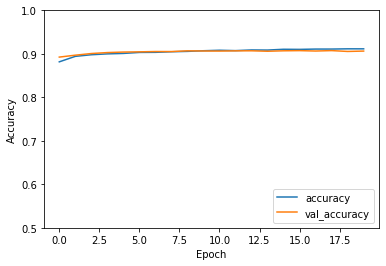

In [0]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

In [0]:
train_predictions_weighted = weighted_model.predict(X_train, batch_size=BATCH_SIZE)
test_predictions_weighted = weighted_model.predict(X_test, batch_size=BATCH_SIZE)

In [0]:
test_predicted = tf.argmax(test_predictions_weighted,1)

Text(0.5, 15.0, 'Predicted label')

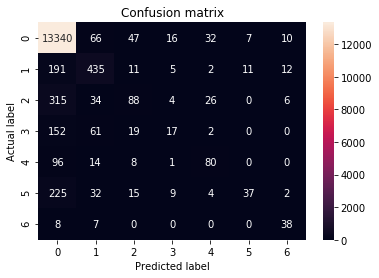

In [0]:
import seaborn as sns
cm = tf.math.confusion_matrix(
    y_test, test_predicted, weights=None, dtype=tf.dtypes.int32,
    name=None
)
sns.heatmap(cm, annot=True, fmt="d")
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [0]:
test_predicted = []
for test_pred in test_predictions_weighted:
  if test_pred[0] > 0.60:
    test_predicted.append(0)
  else:
    test_predicted.append(np.argmax(test_pred[1:])+1)

Text(0.5, 15.0, 'Predicted label')

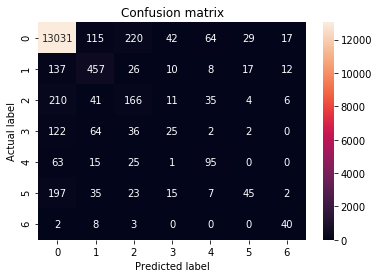

In [0]:
import seaborn as sns
cm = tf.math.confusion_matrix(
    y_test, test_predicted, weights=None, dtype=tf.dtypes.int32,
    name=None
)
sns.heatmap(cm, annot=True, fmt="d")
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [0]:
X_train = train_df
y_train = labels#.map(dic)
train_df_ = train_df.copy()
train_df_["CLASE"] = "RESIDENTIAL"
y_vl_RESIDENTIAL = train_df_["CLASE"]

In [0]:
from sklearn.model_selection import KFold,StratifiedKFold
from sklearn.metrics import accuracy_score
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import make_scorer
import lightgbm as lgb
from hyperopt import hp, tpe
from hyperopt.fmin import fmin

params = {'objective': 'binary',
          'n_estimators': 1000}

In [0]:
params = {'boosting_type': 'gbdt',
          'max_depth' : -1,
          'objective': 'binary',
          'nthread': 3, # Updated from nthread
          'num_leaves': 64,
          'learning_rate': 0.05,
          'max_bin': 512,
          'subsample_for_bin': 200,
          'subsample': 1,
          'subsample_freq': 1,
          'colsample_bytree': 0.8,
          'reg_alpha': 5,
          'reg_lambda': 10,
          'min_split_gain': 0.5,
          'min_child_weight': 1,
          'min_child_samples': 5,
          'scale_pos_weight': 1,
          'metric' : 'binary',
          'n_estimators': 1000
         }

In [0]:
def train_lgbm(params, FOLDS= 3,verbose = 1000, print_ = False):
    
    params = {
        'max_depth': int(params['max_depth']),
        'num_leaves': int(params['num_leaves']),
        'nthread': int(params['nthread']),
        'colsample_bytree': '{:.3f}'.format(params['colsample_bytree']),
        'learning_rate': '{:.3f}'.format(params['learning_rate']),
        'n_estimators': int(params['n_estimators']),
        'bagging_fraction': params['bagging_fraction'],
        'lambda_l1': params['lambda_l1'],
        'lambda_l2': params['lambda_l2'],
        'min_child_weight': params['min_child_weight']
        
    }
    
    print(params)
    kf = KFold(n_splits=FOLDS, random_state=42)
    acc_score = 0
    clfs = []
    for tr_idx, val_idx in kf.split(y_train):
        X_tr, X_vl = X_train.iloc[tr_idx, :].fillna(-99), X_train.iloc[val_idx, :].fillna(-99)
        y_tr, y_vl = y_train.iloc[tr_idx], y_train[val_idx]
        
        
        model_1 = lgb.LGBMClassifier(**params,
                           num_classes = 7, 
                           objective = "multiclass", random_state= 123)

        model_1.fit(X_tr, y_tr, 
          eval_metric = 'multi_logloss',
          eval_set = [(X_vl, y_vl), (X_tr, y_tr)],
          eval_names = ['valid', 'train'], 
          early_stopping_rounds = 50, verbose = 200)



        model_2 = lgb.LGBMClassifier(**params,
                           num_classes = 7, 
                           objective = "multiclass", random_state=2)

        model_2.fit(X_tr, y_tr, 
          eval_metric = 'multi_logloss',
          eval_set = [(X_vl, y_vl), (X_tr, y_tr)],
          eval_names = ['valid', 'train'], 
          early_stopping_rounds = 50, verbose = 200)


        model_3 = lgb.LGBMClassifier(**params,
                           num_classes = 7, 
                           objective = "multiclass", random_state = 435)

        model_3.fit(X_tr, y_tr, 
          eval_metric = 'multi_logloss',
          eval_set = [(X_vl, y_vl), (X_tr, y_tr)],
          eval_names = ['valid', 'train'], 
          early_stopping_rounds = 50, verbose = 200)
            
            
        
        print("-----")
        dictionary = dict(zip(np.argmax(model_1.predict_proba(X_vl),axis=1),model_1.predict(X_vl)))
        numpy_sol_numbers = np.argmax((model_1.predict_proba(X_vl)+model_2.predict_proba(X_vl)+model_3.predict_proba(X_vl))/3,axis=1)

        score = accuracy_score(y_vl,np.vectorize(dictionary.get)(numpy_sol_numbers))

        print("todo RESIDENCIAL:", accuracy_score(y_vl,train_df_.iloc[val_idx, :]["CLASE"]),'CV - score:',score)

        """print('M1', accuracy_score(y_vl,model_1.predict(X_vl)),
              'M2', accuracy_score(y_vl,model_2.predict(X_vl)),
              'M3', accuracy_score(y_vl,model_3.predict(X_vl)))"""
        print("-----")
        clfs.append(model_1)
        clfs.append(model_2)
        clfs.append(model_3)
            
        acc_score += score
        
    total_acc_score = acc_score / FOLDS
    
    print("final score", total_acc_score)
    print("-----------------------")
    print("-----------------------")
    print("-----------------------")
    return -total_acc_score


In [0]:
space = {
    'max_depth': hp.quniform('max_depth', 10, 20, 1),
    'num_leaves': hp.quniform('num_leaves', 30, 150, 1),
    'nthread': hp.quniform('nthread', 1, 10, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.3, 1.0),
    'n_estimators': hp.uniform('n_estimators', 5000, 20000),
    'bagging_fraction': hp.uniform('bagging_fraction', 0.1, 1),
    'lambda_l1': hp.choice('lambda_l1', [0, hp.loguniform('lambda_l1_positive', -16, 2)]),
    'lambda_l2': hp.choice('lambda_l2', [0, hp.loguniform('lambda_l2_positive', -16, 2)]),
    'min_child_weight': hp.loguniform('min_child_weight', -16, 5),
    'learning_rate': hp.uniform('learning_rate', 0.05, 0.01),
}

best = fmin(fn=train_lgbm,
            space=space,
            algo=tpe.suggest,
            max_evals=50)

{'max_depth': 18, 'num_leaves': 134, 'nthread': 5, 'colsample_bytree': '0.904', 'learning_rate': '0.049', 'n_estimators': 7302, 'bagging_fraction': 0.5875184577908119, 'lambda_l1': 0, 'lambda_l2': 5.0945227386348355, 'min_child_weight': 8.293056329420016e-05}
  0%|          | 0/50 [00:00<?, ?it/s, best loss: ?]

/usr/local/lib/python3.6/dist-packages/sklearn/model_selection/_split.py:296: FutureWarning: Setting a random_state has no effect since shuffle is False. This will raise an error in 0.24. You should leave random_state to its default (None), or set shuffle=True.
  FutureWarning



Training until validation scores don't improve for 50 rounds.
[200]	train's multi_logloss: 0.0941557	train's multi_logloss: 0.0941557	valid's multi_logloss: 0.312821	valid's multi_logloss: 0.312821
Early stopping, best iteration is:
[166]	train's multi_logloss: 0.113488	train's multi_logloss: 0.113488	valid's multi_logloss: 0.312111	valid's multi_logloss: 0.312111
Training until validation scores don't improve for 50 rounds.
[200]	train's multi_logloss: 0.0942741	train's multi_logloss: 0.0942741	valid's multi_logloss: 0.313026	valid's multi_logloss: 0.313026
Early stopping, best iteration is:
[159]	train's multi_logloss: 0.118158	train's multi_logloss: 0.118158	valid's multi_logloss: 0.31216	valid's multi_logloss: 0.31216
Training until validation scores don't improve for 50 rounds.
[200]	train's multi_logloss: 0.0941702	train's multi_logloss: 0.0941702	valid's multi_logloss: 0.31197	valid's multi_logloss: 0.31197
Early stopping, best iteration is:
[169]	train's multi_logloss: 0.11147	